In [2]:
from google.colab import drive
from pathlib import Path
import os

drive.mount('/content/drive')

PROJECT_ROOT = Path("/content/drive/MyDrive/Skoltech/Science_Phan")
DATA_DIR     = PROJECT_ROOT / "DIV2K" / "DIV2K_train_HR"
WORK_DIR     = PROJECT_ROOT / "runs"
LIB_DIR      = PROJECT_ROOT / "Lib"
CKPT_DIR     = WORK_DIR / "0008_nina"

for p in (PROJECT_ROOT, DATA_DIR, WORK_DIR, LIB_DIR, CKPT_DIR):
    p.mkdir(parents=True, exist_ok=True)



os.chdir(PROJECT_ROOT)
print("CWD:", os.getcwd())
print("Checkpoints dir:", CKPT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CWD: /content/drive/MyDrive/Skoltech/Science_Phan
Checkpoints dir: /content/drive/MyDrive/Skoltech/Science_Phan/runs/0008_nina


## Checkpoint / Resume (защита от падения Colab)

- Checkpoints сохраняются на Drive: `runs/0008_nina/latest.pt`
- После каждого **outer**-шага ADMM пишется `outer_XXXX.pt`
- Перед первым `# ADMM` — ячейка **Resume** (`DO_RESUME = True`)
- При Ctrl+C или disconnect — загрузи `latest.pt` и продолжай


In [1]:
0

0

In [3]:
# 1. Фиксируем numpy 1.x под compressai
!pip install -q "numpy==1.26.4"

# 2. Пересобираем torch-стек под этот numpy (важно!)
!pip install -q torch torchvision --force-reinstall

# 3. Остальное — без даун/апгрейда numpy
!pip install -q compressai scikit-image kornia piq torchsr torchmetrics

# 4. На всякий случай снова закрепляем numpy
!pip install -q "numpy==1.26.4"

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
compressai 1.2.8 requires numpy<2.0,>=1.21.0, but you have numpy 2.4.6 which is incompatible.
cuda-python 12.9.4 requires cuda-bindings~=12.9.4, but you have cuda-bindings 13.3.1 which is incompatible.
cudf-cu12 26.2.1 requires cuda-toolkit[nvcc,nvrtc]==12.*, but you have cuda-toolkit 13.0.2 which is incompatible.
cuml-cu12 26.2.0 requires cuda-toolkit[cublas,cufft,curand,cusolver,cusparse]==12.*, but you have cuda-toolkit 13.0.2 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.4.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.4.0 which is incompatible.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.
libcuml-cu1

In [4]:
0

0

In [ ]:
# # Load AI compression model

# import importlib.util

# package_name = 'compressai'

# spec = importlib.util.find_spec(package_name)
# if spec is None:
#     print(package_name + " is not installed")
#     !pip install compressai -q

# package_name = 'skimage'
# spec = importlib.util.find_spec(package_name)
# if spec is None:
#     print(package_name + " is not installed")
#     !pip install scikit-image -q

# package_name = 'kornia'
# spec = importlib.util.find_spec(package_name)
# if spec is None:
#     print(package_name + " is not installed")
#     !pip install kornia -q
# !pip install piq -q
# !pip install torchsr -q

In [3]:
import numpy as np
import torch
import torchvision
from torchvision.transforms.functional import to_pil_image, to_tensor
import compressai
from torchsr.models import ninasr_b0

print("numpy:", np.__version__)   # 1.26.4
print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
print("OK")

numpy: 1.26.4
torch: 2.12.0+cu130
cuda: True
OK


In [4]:
import math
import torch
# from torchsr.datasets import
# from torchsr.models import ninasr_b0
from torchvision.transforms.functional import to_pil_image, to_tensor

In [5]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

In [6]:

from torchvision import transforms
import numpy as np

from PIL import Image

import matplotlib.pyplot as plt
import torch.nn.functional as F



In [7]:
import requests
from PIL import Image
from io import BytesIO
import torch
from torchvision.transforms import ToTensor


import random

# Parameters
img_path = str(DATA_DIR / "0008.png")
crop_size = 512  # Size of the cropped window
scaled_size = 256  # Size of the scaled-down version

# Load the original high-resolution image
img = Image.open(img_path).convert('RGB')
width, height = img.size


# Randomly crop a 512x512 window from the original image
if width >= crop_size and height >= crop_size:
    left = random.randint(0, width - crop_size)
    top = random.randint(0, height - crop_size)
    left, top = 1328, 826 # use left, top from my notebook
    right = left + crop_size
    bottom = top + crop_size
    cropped_img = img.crop((left, top, right, bottom))
else:
    raise ValueError("Image dimensions must be at least 512x512.")

# Use the cropped image as ground truth reference
ground_truth = cropped_img
# print(preprocess(cropped_img).shape)
# Resize the cropped image to 256x256 for low-resolution input
low_res_img = cropped_img.resize((scaled_size, scaled_size), Image.BICUBIC)

# Preprocessing transformations
preprocess = transforms.Compose([transforms.ToTensor()])

# Transform to tensor
input_tensor = preprocess(low_res_img).unsqueeze(0).to(device)
ground_truth_tensor = preprocess(ground_truth).unsqueeze(0).to(device)

# Print shapes for verification
print(f"Low-resolution input tensor shape: {input_tensor.shape}")
print(f"Ground truth tensor shape: {ground_truth_tensor.shape}")

Low-resolution input tensor shape: torch.Size([1, 3, 256, 256])
Ground truth tensor shape: torch.Size([1, 3, 512, 512])


In [8]:
# Extract the filename
import os
filename = os.path.basename(img_path)
print(filename[:-4])

0008


In [ ]:
# pip install scikit-image

In [15]:
!pip install -q pytorch-wavelets scipy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 7.1 MB/s eta 0:00:00


In [16]:
# Local compression helpers (Lib/aiimagcomp_atk_lib_3012.py)
import sys
import importlib

lib_path = str(LIB_DIR)
if lib_path not in sys.path:
    sys.path.append(lib_path)

import aiimagcomp_atk_lib_3012
importlib.reload(aiimagcomp_atk_lib_3012)
from aiimagcomp_atk_lib_3012 import *

/usr/local/lib/python3.12/dist-packages/pytorch_wavelets/dtcwt/coeffs.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream


In [ ]:
# Model name
# every has 2 encoders 
model_name = "cheng2020-attn" #'cheng2020-attn' 'cheng2020-anchor' 'mbt2018' 'mbt2018-mean'  'bmshj2018-hyperprior'  'bmshj2018_factorized_relu' 'bmshj2018_factorized'

# Quality
quality = 6
model_name2 = model_name.replace('-', '_')

## Load pretrained AI image compression models
# from compressai.zoo import cheng2020_anchor
from compressai.zoo import models

# Dynamically retrieve the model class
# model_class = models['cheng2020-anchor']
model_class = models[model_name]

# Clear GPU memory
torch.cuda.empty_cache()
# Set compression-decompression quality for AI image compression
model_compression = model_class(quality=quality, pretrained=True).to(device)
for param in model_compression.parameters():
    param.requires_grad = False


# # model_forcompression (CPU)
# net = model_class(quality=quality, pretrained=True,progress=False).eval()


Downloading: "https://compressai.s3.amazonaws.com/models/v1/cheng2020_attn-mse-6-730501f2.pth.tar" to /root/.cache/torch/hub/checkpoints/cheng2020_attn-mse-6-730501f2.pth.tar


100%|██████████| 121M/121M [00:07<00:00, 16.9MB/s] 


In [17]:
# Check the current memory usage on GPU
print(f"Memory allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
print(f"Memory cached: {torch.cuda.memory_reserved() / 1024**2:.2f} MB")


Memory allocated: 127.77 MB
Memory cached: 136.00 MB


In [18]:
torch.cuda.empty_cache()


In [12]:
def eval_perf_compression(model_compression, sr_image_tensor, ref_image_tensor=None):
    # Anh-Huy Phan 2024
    #
    # Forward pass through the compression model
    output_compression = model_compression(sr_image_tensor)

    # Assuming 'output' is a dictionary with key 'x_hat' for the reconstructed image
    # output_final = output_compression['x_hat']


    # Check the bitrate of compressed file for the superresolution image : sr_image_tensor
    # Compress the super resolution image
    MAX_I = 1.

    num_pixels = sr_image_tensor.shape[2] * sr_image_tensor.shape[3]
    # model and net are the same , but net is on cpu and for compression

    mse_loss_original = F.mse_loss(output_compression['x_hat'].clamp_(0, 1), sr_image_tensor)
    target_psnr = 10 * torch.log10((MAX_I ** 2) / mse_loss_original)

    # Compute bpp loss (to be maximized, hence the negative sign)
    baseline_bpp = (torch.log(output_compression['likelihoods']['y']).sum() + \
        torch.log(output_compression['likelihoods']['z']).sum()) / (-math.log(2) * num_pixels)

    target_ssim = ssim(output_compression['x_hat'].clamp_(0, 1), sr_image_tensor)


    compressfile = str(WORK_DIR / "0008compress")
    bitdepth = 8
    h, w = sr_image_tensor.size(2), sr_image_tensor.size(3)

    with torch.no_grad():
        sr_output = model_compression.compress(sr_image_tensor)
        # sr_output = net.compress(sr_image_tensor.to('cpu'))


    baseline_true_bpp = savecompressed(compressfile, sr_output, bitdepth, h, w)


    if ref_image_tensor is not None:
        vs_ref_ssim = ssim(output_compression['x_hat'].clamp_(0, 1), ref_image_tensor)
        mse_ref = F.mse_loss(output_compression['x_hat'].clamp_(0, 1), ref_image_tensor)
        vs_ref_psnr = 10 * torch.log10((MAX_I ** 2) / mse_ref)

        sr_compression_result = {'PSNR': target_psnr.cpu().detach().numpy(), 'Bpp': baseline_bpp.cpu().detach().numpy(), 'Bpp(fsize)': baseline_true_bpp, 'SSIM' : target_ssim.cpu().detach().numpy(), \
                                'PSNR_cmpref': vs_ref_psnr.cpu().detach().numpy(), 'SSI_cmpref': vs_ref_ssim.cpu().detach().numpy()}

    else:
        vs_ref_ssim = None
        vs_ref_psnr = None


        sr_compression_result = {'PSNR': target_psnr.cpu().detach().numpy(), 'Bpp' : baseline_bpp.cpu().detach().numpy(), 'Bpp(fsize)': baseline_true_bpp, 'SSIM' : target_ssim.cpu().detach().numpy(), \
                                'PSNR_cmpref': None, 'SSI_cmpref': None}
    return sr_compression_result

In [19]:
# import torch
import torchvision.transforms as transforms
from torchvision.transforms.functional import resize
from torchvision.transforms import InterpolationMode

# Example Usage:
from PIL import Image


interpolation_methods = [InterpolationMode.NEAREST, InterpolationMode.BILINEAR, InterpolationMode.BICUBIC]
target_size = [ground_truth_tensor.shape[2], ground_truth_tensor.shape[3]]
# Store Results
baseline_sr_results = []

# Loop through interpolation methods
for method in interpolation_methods:
    resized_image = resize(input_tensor, target_size, interpolation=method)

    # Evaluate performance with the resized image
    sr_compression_result_interp = eval_perf_compression(model_compression, resized_image, ground_truth_tensor)

    # Append result to the list
    baseline_sr_results.append(sr_compression_result_interp)

baseline_sr_results

/tmp/ipykernel_9390/1750059163.py:33: UserWarning: Inference on GPU is not recommended for the autoregressive models (the entropy coder is run sequentially on CPU).
  sr_output = model_compression.compress(sr_image_tensor)


[{'PSNR': array(33.162262, dtype=float32),
  'Bpp': array(1.2745446, dtype=float32),
  'Bpp(fsize)': 1.206451416015625,
  'SSIM': array(0.02922462, dtype=float32),
  'PSNR_cmpref': array(25.464651, dtype=float32),
  'SSI_cmpref': array(0.08608275, dtype=float32)},
 {'PSNR': array(36.905064, dtype=float32),
  'Bpp': array(0.77758557, dtype=float32),
  'Bpp(fsize)': 0.666900634765625,
  'SSIM': array(0.01620233, dtype=float32),
  'PSNR_cmpref': array(25.581451, dtype=float32),
  'SSI_cmpref': array(0.09474851, dtype=float32)},
 {'PSNR': array(35.746845, dtype=float32),
  'Bpp': array(0.89696914, dtype=float32),
  'Bpp(fsize)': 0.790802001953125,
  'SSIM': array(0.01841858, dtype=float32),
  'PSNR_cmpref': array(26.59946, dtype=float32),
  'SSI_cmpref': array(0.07771316, dtype=float32)}]

In [20]:
import copy
from pathlib import Path


def _save_admm_checkpoint(state, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(state, path)
    torch.save(state, path.parent / "latest.pt")


def load_admm_checkpoint(path, model_supres, device):
    ckpt = torch.load(path, map_location=device)
    model_supres.load_state_dict(ckpt["model_supres"])
    return {
        "Z_tensor": ckpt["Z_tensor"].to(device),
        "T_tensor": ckpt["T_tensor"].to(device),
        "start_outer": int(ckpt.get("outer_index", 0)),
        "optimizer_state": ckpt.get("optimizer"),
        "loss_values": list(ckpt.get("loss_values", [])),
        "bpp_values": list(ckpt.get("bpp_values", [])),
        "psnr_values": list(ckpt.get("psnr_values", [])),
        "target_psnr": ckpt.get("target_psnr"),
        "quality_loss_lambda": ckpt.get("quality_loss_lambda"),
        "num_iterations": ckpt.get("num_iterations"),
        "learningrate": ckpt.get("learningrate"),
    }


def minbitrate_superresolution(
    input_tensor,
    sr_image_tensor_orig,
    target_psnr,
    quality_loss_lambda,
    num_iterations,
    model_supres,
    model_compression,
    device=None,
    learningrate=1e-3,
    Z_tensor=None,
    T_tensor=None,
    checkpoint_dir=None,
    checkpoint_interval=1,
    start_outer=0,
    loss_values=None,
    bpp_values=None,
    psnr_values=None,
    optimizer_state=None,
):
    """ADMM SR + compression. Saves checkpoint every outer step to checkpoint_dir."""
    if device is None:
        device = input_tensor.device

    if sr_image_tensor_orig is None:
        with torch.no_grad():
            out_ref = model_supres(input_tensor)
            sr_image_tensor_orig = out_ref.reconstruction if hasattr(out_ref, "reconstruction") else out_ref
        sr_image_tensor_orig = sr_image_tensor_orig.detach()

    MAX_I = 1.0
    num_pixels = sr_image_tensor_orig.shape[0] * sr_image_tensor_orig.shape[2] * sr_image_tensor_orig.shape[3]

    if Z_tensor is None:
        Z_tensor = copy.deepcopy(sr_image_tensor_orig)
    if T_tensor is None:
        T_tensor = torch.zeros_like(sr_image_tensor_orig)

    delta_squared = sr_image_tensor_orig.shape[1] * num_pixels * (MAX_I ** 2) / (10 ** (target_psnr / 10))
    delta = torch.sqrt(torch.tensor(delta_squared, device=device, dtype=sr_image_tensor_orig.dtype))

    trainable_params = [p for p in model_supres.parameters() if p.requires_grad]
    if len(trainable_params) == 0:
        raise RuntimeError("No trainable parameters found in model_supres.")

    optimizer = torch.optim.Adam(trainable_params, lr=learningrate)
    if optimizer_state is not None:
        optimizer.load_state_dict(optimizer_state)

    outer_iterations = 20
    loss_values = list(loss_values or [])
    bpp_values = list(bpp_values or [])
    psnr_values = list(psnr_values or [])

    def _write_checkpoint(outer_idx):
        if not checkpoint_dir:
            return
        state = {
            "model_supres": model_supres.state_dict(),
            "Z_tensor": Z_tensor.detach().cpu(),
            "T_tensor": T_tensor.detach().cpu(),
            "outer_index": outer_idx,
            "optimizer": optimizer.state_dict(),
            "loss_values": loss_values,
            "bpp_values": bpp_values,
            "psnr_values": psnr_values,
            "target_psnr": float(target_psnr),
            "quality_loss_lambda": float(quality_loss_lambda),
            "num_iterations": int(num_iterations),
            "learningrate": float(learningrate),
        }
        ckpt_path = Path(checkpoint_dir) / f"outer_{outer_idx - 1:04d}.pt"
        _save_admm_checkpoint(state, ckpt_path)
        print(f"Checkpoint saved: outer {outer_idx}/{outer_iterations} -> {ckpt_path}")

    ki = start_outer
    try:
        for ki in range(start_outer, outer_iterations):
            ZT = Z_tensor + T_tensor
            sr_image_tensor = None

            for iteration in range(num_iterations):
                optimizer.zero_grad()

                out_sr = model_supres(input_tensor)
                sr_image_tensor = out_sr.reconstruction if hasattr(out_sr, "reconstruction") else out_sr

                sr_compression = model_compression(sr_image_tensor)
                decompressed_sr_image = sr_compression["x_hat"]

                bpploss = bpp_loss(sr_compression, num_pixels)

                mse_loss = F.mse_loss(decompressed_sr_image, sr_image_tensor_orig)
                psnr_quality_compressed_sr_vs_ref = 10 * torch.log10((MAX_I ** 2) / (mse_loss + 1e-8))
                zero_scalar = torch.zeros((), device=sr_image_tensor.device, dtype=sr_image_tensor.dtype)
                quality_loss_compressed_sr_vs_ref2 = torch.maximum(
                    (psnr_quality_compressed_sr_vs_ref - target_psnr).abs() - 0.5, zero_scalar
                )

                mse_loss2 = F.mse_loss(sr_image_tensor, ZT)
                psnr_quality_sr_vs_ref = 10 * torch.log10((MAX_I ** 2) / (mse_loss2 + 1e-8))
                quality_loss_sr_vs_ref2 = torch.maximum(
                    (psnr_quality_sr_vs_ref - target_psnr).abs() - 0.5, zero_scalar
                )

                combined_loss = (
                    10 * torch.log10((bpploss) + 1e-8)
                    + quality_loss_lambda * quality_loss_compressed_sr_vs_ref2
                    + quality_loss_lambda * quality_loss_sr_vs_ref2
                )

                combined_loss.backward()
                optimizer.step()

                if iteration % 30 == 0:
                    print(
                        f"Outer {ki} | Iter {iteration} | PSNR cmp: {psnr_quality_compressed_sr_vs_ref:.2f} "
                        f"| BPP: {bpploss:.4f} | Loss: {combined_loss:.4f}"
                    )

                loss_values.append(combined_loss.item())
                bpp_values.append(bpploss.item())
                psnr_values.append(psnr_quality_sr_vs_ref.item())

            D = sr_image_tensor - T_tensor
            E = D - sr_image_tensor_orig
            normE = torch.linalg.norm(E.reshape(-1))
            if normE <= delta:
                Z_tensor = D.clone()
            else:
                Z_tensor = sr_image_tensor_orig + delta * E / normE

            Z_tensor = Z_tensor.detach()
            T_tensor = (T_tensor + Z_tensor - sr_image_tensor).detach()

            if checkpoint_interval and ((ki + 1) % checkpoint_interval == 0 or ki == outer_iterations - 1):
                _write_checkpoint(ki + 1)

    except KeyboardInterrupt:
        interrupted_outer = ki + 1 if ki >= start_outer else start_outer
        if checkpoint_dir:
            state = {
                "model_supres": model_supres.state_dict(),
                "Z_tensor": Z_tensor.detach().cpu(),
                "T_tensor": T_tensor.detach().cpu(),
                "outer_index": interrupted_outer,
                "optimizer": optimizer.state_dict(),
                "loss_values": loss_values,
                "bpp_values": bpp_values,
                "psnr_values": psnr_values,
                "target_psnr": float(target_psnr),
                "quality_loss_lambda": float(quality_loss_lambda),
                "num_iterations": int(num_iterations),
                "learningrate": float(learningrate),
            }
            _save_admm_checkpoint(state, Path(checkpoint_dir) / "interrupt.pt")
            print(f"Interrupted, checkpoint saved -> {Path(checkpoint_dir) / 'latest.pt'}")
        return model_supres, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values

    return model_supres, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values


In [ ]:
# pip install transformers[torch]


  Using cached transformers-4.46.3-py3-none-any.whl.metadata (44 kB)
  Using cached regex-2024.11.6-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (40 kB)
  Using cached tokenizers-0.20.3-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.7 kB)
Using cached regex-2024.11.6-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (785 kB)
Using cached tokenizers-0.20.3-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.0 MB)
Using cached transformers-4.46.3-py3-none-any.whl (10.0 MB)
Note: you may need to restart the kernel to use updated packages.


In [21]:
from torchsr.models import ninasr_b0

# Load pretrained NinaSR backbone for x2 super-resolution.
model = ninasr_b0(scale=2, pretrained=True).to(device)

# Train all Nina parameters in ADMM inner loop.
for p in model.parameters():
    p.requires_grad = True

num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
num_total_params = sum(p.numel() for p in model.parameters())
print(f"{num_trainable_params=}")
print(f"{num_total_params=}")

Downloading: "https://github.com/Coloquinte/torchSR/releases/download/v1.0.3/ninasr_b0_x2.pt" to /root/.cache/torch/hub/checkpoints/ninasr_b0_x2.pt


100%|██████████| 408k/408k [00:00<00:00, 19.4MB/s]

num_trainable_params=100178
num_total_params=100178


In [22]:
# Generate superresolution from input_tensor
with torch.no_grad():
    out_ref = model(input_tensor)
    sr_image_tensor_orig = out_ref.reconstruction if hasattr(out_ref, "reconstruction") else out_ref
sr_image_tensor_orig = sr_image_tensor_orig.detach()  # Detaches it from any computational graph

In [23]:
# Evaluate performance with the resized image
sr_compression_result_spnet = eval_perf_compression(model_compression, sr_image_tensor_orig, ground_truth_tensor)
sr_compression_result_spnet

/tmp/ipykernel_9390/1750059163.py:33: UserWarning: Inference on GPU is not recommended for the autoregressive models (the entropy coder is run sequentially on CPU).
  sr_output = model_compression.compress(sr_image_tensor)


{'PSNR': array(33.18644, dtype=float32),
 'Bpp': array(1.1582186, dtype=float32),
 'Bpp(fsize)': 1.071807861328125,
 'SSIM': array(0.02491618, dtype=float32),
 'PSNR_cmpref': array(28.328245, dtype=float32),
 'SSI_cmpref': array(0.05676104, dtype=float32)}

In [24]:
# Resume ADMM from Drive checkpoint (set DO_RESUME=False to start fresh)
DO_RESUME = True
RESUME_PATH = CKPT_DIR / "latest.pt"  # or CKPT_DIR / "interrupt.pt"

start_outer = 0
optimizer_state = None
loss_values_hist, bpp_values_hist, psnr_values_hist = [], [], []

if DO_RESUME and RESUME_PATH.exists():
    resume = load_admm_checkpoint(RESUME_PATH, model, device)
    Z_tensor = resume["Z_tensor"]
    T_tensor = resume["T_tensor"]
    start_outer = resume["start_outer"]
    optimizer_state = resume["optimizer_state"]
    loss_values_hist = resume["loss_values"]
    bpp_values_hist = resume["bpp_values"]
    psnr_values_hist = resume["psnr_values"]
    print(f"Resumed from {RESUME_PATH}")
    print(f"  outer_index={start_outer}, history len={len(loss_values_hist)}")
    if start_outer >= 20:
        print("  Previous run finished — resetting start_outer=0 for this block.")
        start_outer = 0
    if resume["target_psnr"] is not None:
        print(f"  saved hyperparams: target_psnr={resume['target_psnr']}, lambda={resume['quality_loss_lambda']}")
else:
    Z_tensor = copy.deepcopy(sr_image_tensor_orig)
    T_tensor = torch.zeros_like(sr_image_tensor_orig)
    print("No checkpoint found — starting fresh ADMM state.")


No checkpoint found — starting fresh ADMM state.


Outer 0 | Iter 0 | PSNR cmp: 33.20 | BPP: 1.1565 | Loss: 46.4302
Outer 0 | Iter 30 | PSNR cmp: 31.33 | BPP: 1.0812 | Loss: 3.5040
Outer 0 | Iter 60 | PSNR cmp: 32.12 | BPP: 1.0930 | Loss: 2.7670
Outer 0 | Iter 90 | PSNR cmp: 33.19 | BPP: 1.1364 | Loss: 1.8676
Checkpoint saved: outer 1/20 -> /content/drive/MyDrive/Skoltech/Science_Phan/runs/0008_nina/outer_0000.pt
Outer 1 | Iter 0 | PSNR cmp: 33.23 | BPP: 1.1369 | Loss: 27.2614
Outer 1 | Iter 30 | PSNR cmp: 33.19 | BPP: 1.1430 | Loss: 2.8286
Outer 1 | Iter 60 | PSNR cmp: 33.32 | BPP: 1.1452 | Loss: 1.7683
Outer 1 | Iter 90 | PSNR cmp: 33.35 | BPP: 1.1463 | Loss: 1.7399
Checkpoint saved: outer 2/20 -> /content/drive/MyDrive/Skoltech/Science_Phan/runs/0008_nina/outer_0001.pt
Outer 2 | Iter 0 | PSNR cmp: 33.39 | BPP: 1.1472 | Loss: 5.6297
Outer 2 | Iter 30 | PSNR cmp: 33.41 | BPP: 1.1370 | Loss: 1.6747
Outer 2 | Iter 60 | PSNR cmp: 33.51 | BPP: 1.1350 | Loss: 1.5376
Outer 2 | Iter 90 | PSNR cmp: 33.54 | BPP: 1.1372 | Loss: 1.5135
Checkpoin

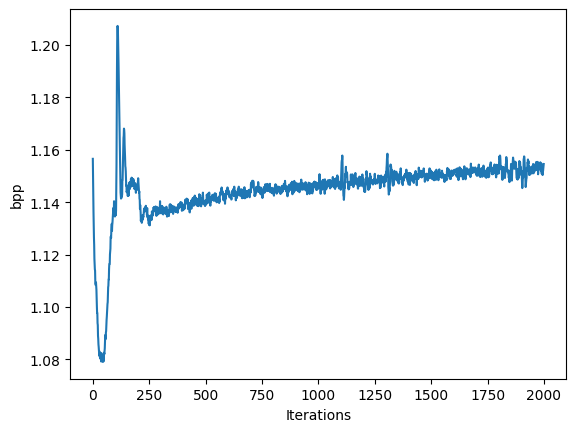

In [25]:
# ADMM
quality_loss_lambda = 1  # hyperparameter
num_iterations = 100
target_psnr = 35  # hyperparameter

model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(
    input_tensor, sr_image_tensor_orig, target_psnr,
    quality_loss_lambda, num_iterations, model, model_compression,
    device=device, learningrate=1e-4,
    Z_tensor=Z_tensor, T_tensor=T_tensor,
    checkpoint_dir=CKPT_DIR, start_outer=start_outer,
    loss_values=loss_values_hist, bpp_values=bpp_values_hist, psnr_values=psnr_values_hist,
    optimizer_state=optimizer_state,
)
loss_values_, bpp_values_, psnr_values_ = loss_values, bpp_values, psnr_values
plt.plot(bpp_values_)
plt.xlabel("Iterations")
plt.ylabel("bpp")
plt.show()


In [26]:
sr_image_tensor_orig = sr_image_tensor_orig.detach()  # Detaches it from any computational graph

In [27]:
import pickle

results = {
    "filename": filename,
    "psnr": psnr_values_,
    "loss_values": loss_values_,
    "bpp_values":bpp_values_,
}

results_file = f"result_2x_{filename}.pkl"
with open(results_file, "wb") as f:
    pickle.dump(results, f)
    
    

In [28]:
# Evaluate performance with the resized image
sr_compression_result_spnet_bitmin = eval_perf_compression(model_compression, Z_tensor, ground_truth_tensor)
sr_compression_result_spnet_bitmin

/tmp/ipykernel_9390/1750059163.py:33: UserWarning: Inference on GPU is not recommended for the autoregressive models (the entropy coder is run sequentially on CPU).
  sr_output = model_compression.compress(sr_image_tensor)


{'PSNR': array(31.991936, dtype=float32),
 'Bpp': array(1.1543974, dtype=float32),
 'Bpp(fsize)': 1.064117431640625,
 'SSIM': array(0.04734692, dtype=float32),
 'PSNR_cmpref': array(28.500502, dtype=float32),
 'SSI_cmpref': array(0.05572651, dtype=float32)}

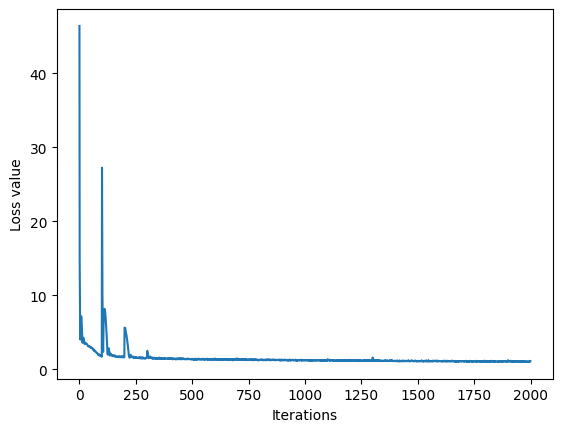

In [29]:
plt.plot(loss_values_)
plt.xlabel("Iterations")
plt.ylabel("Loss value")
plt.show()

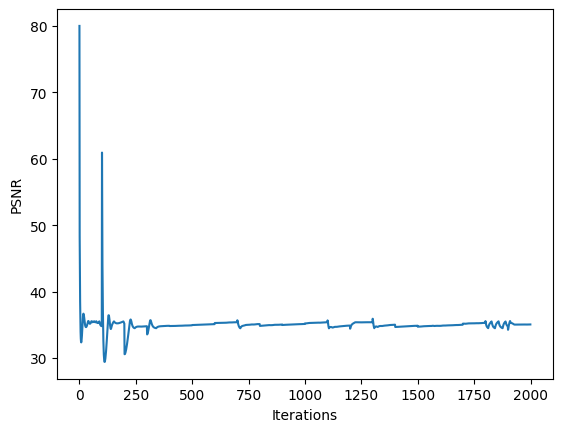

In [30]:
plt.plot(psnr_values_)
plt.xlabel("Iterations")
plt.ylabel("PSNR")
plt.show()

In [31]:
bpp_values_ = np.array(bpp_values_)

np.min(bpp_values_[np.abs(np.array(psnr_values_)-np.float32(target_psnr))<=1e-2])

1.1364680528640747

Outer 0 | Iter 0 | PSNR cmp: 34.05 | BPP: 1.1537 | Loss: 0.9823
Checkpoint saved: outer 1/20 -> /content/drive/MyDrive/Skoltech/Science_Phan/runs/0008_nina/outer_0000.pt
Outer 1 | Iter 0 | PSNR cmp: 33.95 | BPP: 1.1403 | Loss: 1.0518
Checkpoint saved: outer 2/20 -> /content/drive/MyDrive/Skoltech/Science_Phan/runs/0008_nina/outer_0001.pt
Outer 2 | Iter 0 | PSNR cmp: 34.05 | BPP: 1.1393 | Loss: 0.9276
Checkpoint saved: outer 3/20 -> /content/drive/MyDrive/Skoltech/Science_Phan/runs/0008_nina/outer_0002.pt
Outer 3 | Iter 0 | PSNR cmp: 34.02 | BPP: 1.1422 | Loss: 1.1175
Checkpoint saved: outer 4/20 -> /content/drive/MyDrive/Skoltech/Science_Phan/runs/0008_nina/outer_0003.pt
Outer 4 | Iter 0 | PSNR cmp: 34.01 | BPP: 1.1398 | Loss: 0.9584
Checkpoint saved: outer 5/20 -> /content/drive/MyDrive/Skoltech/Science_Phan/runs/0008_nina/outer_0004.pt
Outer 5 | Iter 0 | PSNR cmp: 34.01 | BPP: 1.1373 | Loss: 0.9544
Checkpoint saved: outer 6/20 -> /content/drive/MyDrive/Skoltech/Science_Phan/runs/0008

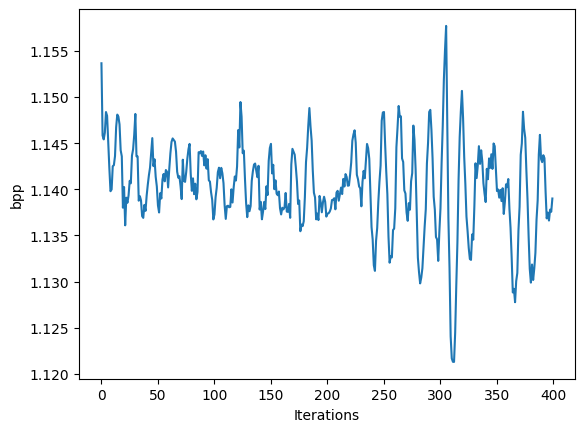

In [32]:
# ADMM
 
quality_loss_lambda = .8
# num_iterations = 100
num_iterations = 20
target_psnr = 35

model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(input_tensor,sr_image_tensor_orig, target_psnr,
                           quality_loss_lambda, num_iterations, model, model_compression, device=device, learningrate = 1e-4, Z_tensor=Z_tensor, T_tensor=T_tensor,
                           checkpoint_dir=CKPT_DIR)
loss_values_, bpp_values_, psnr_values_ = loss_values, bpp_values, psnr_values
plt.plot(bpp_values_)
plt.xlabel("Iterations")
plt.ylabel("bpp")
plt.show()

Outer 0 | Iter 0 | PSNR cmp: 34.08 | BPP: 1.1405 | Loss: 0.9044
Outer 0 | Iter 30 | PSNR cmp: 34.08 | BPP: 1.1412 | Loss: 0.9130
Outer 0 | Iter 60 | PSNR cmp: 34.12 | BPP: 1.1414 | Loss: 0.8744
Outer 0 | Iter 90 | PSNR cmp: 34.08 | BPP: 1.1393 | Loss: 0.9051
Checkpoint saved: outer 1/20 -> /content/drive/MyDrive/Skoltech/Science_Phan/runs/0008_nina/outer_0000.pt
Outer 1 | Iter 0 | PSNR cmp: 34.11 | BPP: 1.1421 | Loss: 1.1970
Outer 1 | Iter 30 | PSNR cmp: 33.98 | BPP: 1.1340 | Loss: 0.9642
Outer 1 | Iter 60 | PSNR cmp: 34.04 | BPP: 1.1311 | Loss: 0.9006
Outer 1 | Iter 90 | PSNR cmp: 34.12 | BPP: 1.1388 | Loss: 0.8693
Checkpoint saved: outer 2/20 -> /content/drive/MyDrive/Skoltech/Science_Phan/runs/0008_nina/outer_0001.pt
Outer 2 | Iter 0 | PSNR cmp: 34.07 | BPP: 1.1416 | Loss: 0.9162
Outer 2 | Iter 30 | PSNR cmp: 34.08 | BPP: 1.1402 | Loss: 0.9026
Outer 2 | Iter 60 | PSNR cmp: 34.09 | BPP: 1.1414 | Loss: 0.9042
Outer 2 | Iter 90 | PSNR cmp: 34.13 | BPP: 1.1423 | Loss: 0.8767
Checkpoint 

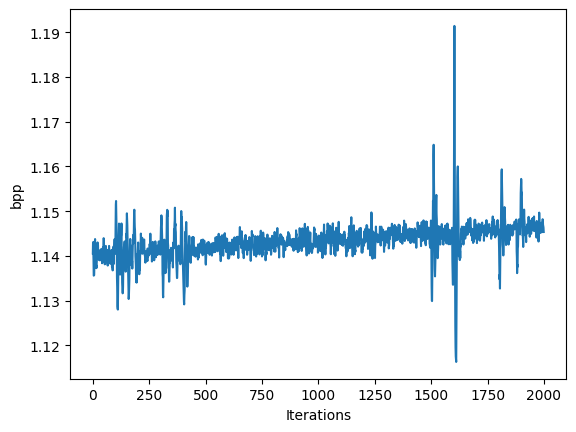

In [33]:
# ADMM
 
quality_loss_lambda = .8
num_iterations = 100
target_psnr = 35

model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(input_tensor,sr_image_tensor_orig, target_psnr,
                           quality_loss_lambda, num_iterations, model, model_compression, device=device, learningrate = 1e-4, Z_tensor=Z_tensor, T_tensor=T_tensor,
                           checkpoint_dir=CKPT_DIR)
loss_values_, bpp_values_, psnr_values_ = loss_values, bpp_values, psnr_values
plt.plot(bpp_values_)
plt.xlabel("Iterations")
plt.ylabel("bpp")
plt.show()

Outer 0 | Iter 0 | PSNR cmp: 34.28 | BPP: 1.1437 | Loss: 0.9413
Outer 0 | Iter 30 | PSNR cmp: 34.31 | BPP: 1.1459 | Loss: 0.7459
Outer 0 | Iter 60 | PSNR cmp: 34.37 | BPP: 1.1470 | Loss: 0.7019
Outer 0 | Iter 90 | PSNR cmp: 34.33 | BPP: 1.1448 | Loss: 0.7269
Checkpoint saved: outer 1/20 -> /content/drive/MyDrive/Skoltech/Science_Phan/runs/0008_nina/outer_0000.pt
Outer 1 | Iter 0 | PSNR cmp: 34.32 | BPP: 1.1489 | Loss: 0.7449
Outer 1 | Iter 30 | PSNR cmp: 34.30 | BPP: 1.1481 | Loss: 0.7592
Outer 1 | Iter 60 | PSNR cmp: 34.31 | BPP: 1.1457 | Loss: 0.7436
Outer 1 | Iter 90 | PSNR cmp: 34.33 | BPP: 1.1453 | Loss: 0.7251
Checkpoint saved: outer 2/20 -> /content/drive/MyDrive/Skoltech/Science_Phan/runs/0008_nina/outer_0001.pt
Outer 2 | Iter 0 | PSNR cmp: 34.32 | BPP: 1.1481 | Loss: 0.7463
Outer 2 | Iter 30 | PSNR cmp: 34.37 | BPP: 1.1469 | Loss: 0.7029
Outer 2 | Iter 60 | PSNR cmp: 34.36 | BPP: 1.1482 | Loss: 0.7125
Outer 2 | Iter 90 | PSNR cmp: 34.32 | BPP: 1.1485 | Loss: 0.7415
Checkpoint 

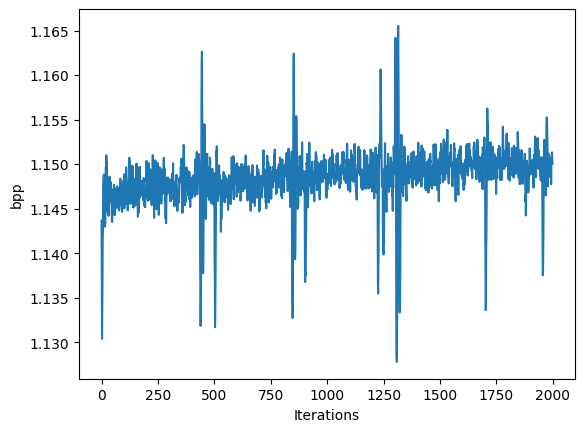

In [34]:
# ADMM
 
quality_loss_lambda = .8
num_iterations = 100
target_psnr = 35

model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(input_tensor,sr_image_tensor_orig, target_psnr,
                           quality_loss_lambda, num_iterations, model, model_compression, device=device, learningrate = 1e-4, Z_tensor=Z_tensor, T_tensor=T_tensor,
                           checkpoint_dir=CKPT_DIR)
loss_values_, bpp_values_, psnr_values_ = loss_values, bpp_values, psnr_values
plt.plot(bpp_values_)
plt.xlabel("Iterations")
plt.ylabel("bpp")
plt.show()

Outer 0 | Iter 0 | PSNR cmp: 34.43 | BPP: 1.1500 | Loss: 0.7323
Outer 0 | Iter 30 | PSNR cmp: 34.36 | BPP: 1.1361 | Loss: 0.6369
Outer 0 | Iter 60 | PSNR cmp: 34.38 | BPP: 1.1331 | Loss: 0.6134
Outer 0 | Iter 90 | PSNR cmp: 34.35 | BPP: 1.1327 | Loss: 0.6333
Checkpoint saved: outer 1/20 -> /content/drive/MyDrive/Skoltech/Science_Phan/runs/0008_nina/outer_0000.pt
Outer 1 | Iter 0 | PSNR cmp: 34.32 | BPP: 1.1304 | Loss: 0.6390
Outer 1 | Iter 30 | PSNR cmp: 34.34 | BPP: 1.1312 | Loss: 0.6316
Outer 1 | Iter 60 | PSNR cmp: 34.30 | BPP: 1.1303 | Loss: 0.6501
Outer 1 | Iter 90 | PSNR cmp: 34.30 | BPP: 1.1279 | Loss: 0.6447
Checkpoint saved: outer 2/20 -> /content/drive/MyDrive/Skoltech/Science_Phan/runs/0008_nina/outer_0001.pt
Outer 2 | Iter 0 | PSNR cmp: 34.31 | BPP: 1.1281 | Loss: 0.8229
Outer 2 | Iter 30 | PSNR cmp: 34.34 | BPP: 1.1287 | Loss: 0.6219
Outer 2 | Iter 60 | PSNR cmp: 34.36 | BPP: 1.1271 | Loss: 0.6016
Outer 2 | Iter 90 | PSNR cmp: 34.33 | BPP: 1.1285 | Loss: 0.6266
Checkpoint 

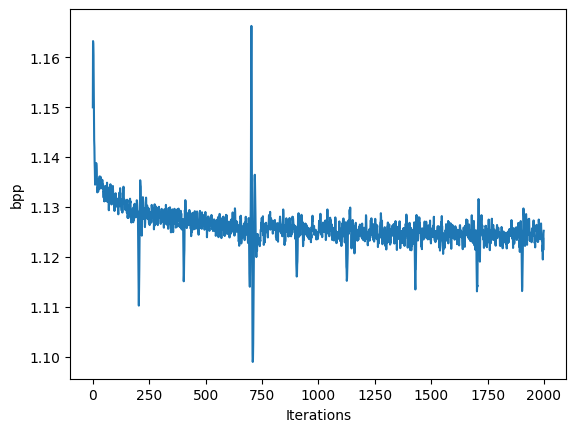

In [35]:
# ADMM
 
quality_loss_lambda = .6
num_iterations = 100
target_psnr = 35

model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(input_tensor,sr_image_tensor_orig, target_psnr,
                           quality_loss_lambda, num_iterations, model, model_compression, device=device, learningrate = 1e-4, Z_tensor=Z_tensor, T_tensor=T_tensor,
                           checkpoint_dir=CKPT_DIR)
loss_values_, bpp_values_, psnr_values_ = loss_values, bpp_values, psnr_values
plt.plot(bpp_values_)
plt.xlabel("Iterations")
plt.ylabel("bpp")
plt.show()

In [36]:
# Evaluate performance with the resized image
sr_compression_result_spnet_bitmin = eval_perf_compression(model_compression, Z_tensor, ground_truth_tensor)
sr_compression_result_spnet_bitmin

/tmp/ipykernel_9390/1750059163.py:33: UserWarning: Inference on GPU is not recommended for the autoregressive models (the entropy coder is run sequentially on CPU).
  sr_output = model_compression.compress(sr_image_tensor)


{'PSNR': array(32.444958, dtype=float32),
 'Bpp': array(1.1252556, dtype=float32),
 'Bpp(fsize)': 1.033966064453125,
 'SSIM': array(0.03211316, dtype=float32),
 'PSNR_cmpref': array(28.56334, dtype=float32),
 'SSI_cmpref': array(0.05623209, dtype=float32)}

Outer 0 | Iter 0 | PSNR cmp: 34.39 | BPP: 1.1245 | Loss: 0.5779
Outer 0 | Iter 30 | PSNR cmp: 34.34 | BPP: 1.1235 | Loss: 0.6034
Outer 0 | Iter 60 | PSNR cmp: 34.39 | BPP: 1.1248 | Loss: 0.5761
Outer 0 | Iter 90 | PSNR cmp: 34.39 | BPP: 1.1263 | Loss: 0.5834
Checkpoint saved: outer 1/20 -> /content/drive/MyDrive/Skoltech/Science_Phan/runs/0008_nina/outer_0000.pt
Outer 1 | Iter 0 | PSNR cmp: 34.40 | BPP: 1.1216 | Loss: 0.5592
Outer 1 | Iter 30 | PSNR cmp: 34.29 | BPP: 1.1252 | Loss: 0.6411
Outer 1 | Iter 60 | PSNR cmp: 34.35 | BPP: 1.1252 | Loss: 0.6040
Outer 1 | Iter 90 | PSNR cmp: 34.40 | BPP: 1.1261 | Loss: 0.5778
Checkpoint saved: outer 2/20 -> /content/drive/MyDrive/Skoltech/Science_Phan/runs/0008_nina/outer_0001.pt
Outer 2 | Iter 0 | PSNR cmp: 34.38 | BPP: 1.1244 | Loss: 0.7289
Outer 2 | Iter 30 | PSNR cmp: 34.35 | BPP: 1.1256 | Loss: 0.6049
Outer 2 | Iter 60 | PSNR cmp: 34.36 | BPP: 1.1222 | Loss: 0.5864
Outer 2 | Iter 90 | PSNR cmp: 34.38 | BPP: 1.1257 | Loss: 0.5838
Checkpoint 

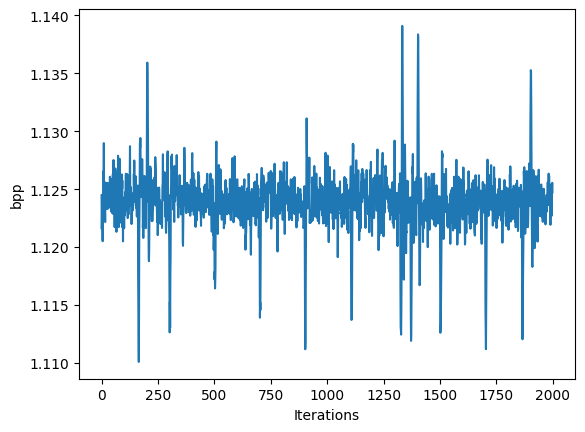

In [37]:
# ADMM
 
quality_loss_lambda = .6
num_iterations = 100
target_psnr = 35

model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(input_tensor,sr_image_tensor_orig, target_psnr,
                           quality_loss_lambda, num_iterations, model, model_compression, device=device, learningrate = 1e-4, Z_tensor=Z_tensor, T_tensor=T_tensor,
                           checkpoint_dir=CKPT_DIR)
loss_values_, bpp_values_, psnr_values_ = loss_values, bpp_values, psnr_values
plt.plot(bpp_values_)
plt.xlabel("Iterations")
plt.ylabel("bpp")
plt.show()

In [38]:
sr_compression_result_spnet_bitmin = eval_perf_compression(model_compression, Z_tensor, ground_truth_tensor)
sr_compression_result_spnet_bitmin

/tmp/ipykernel_9390/1750059163.py:33: UserWarning: Inference on GPU is not recommended for the autoregressive models (the entropy coder is run sequentially on CPU).
  sr_output = model_compression.compress(sr_image_tensor)


{'PSNR': array(32.513718, dtype=float32),
 'Bpp': array(1.124712, dtype=float32),
 'Bpp(fsize)': 1.033111572265625,
 'SSIM': array(0.03141661, dtype=float32),
 'PSNR_cmpref': array(28.56632, dtype=float32),
 'SSI_cmpref': array(0.05596915, dtype=float32)}

Outer 0 | Iter 0 | PSNR cmp: 34.43 | BPP: 1.1239 | Loss: 0.5576
Outer 0 | Iter 30 | PSNR cmp: 34.32 | BPP: 1.1104 | Loss: 0.5449
Outer 0 | Iter 60 | PSNR cmp: 34.36 | BPP: 1.1110 | Loss: 0.5288
Outer 0 | Iter 90 | PSNR cmp: 34.35 | BPP: 1.1088 | Loss: 0.5213
Checkpoint saved: outer 1/20 -> /content/drive/MyDrive/Skoltech/Science_Phan/runs/0008_nina/outer_0000.pt
Outer 1 | Iter 0 | PSNR cmp: 34.36 | BPP: 1.1098 | Loss: 0.6250
Outer 1 | Iter 30 | PSNR cmp: 34.29 | BPP: 1.1109 | Loss: 0.5593
Outer 1 | Iter 60 | PSNR cmp: 34.34 | BPP: 1.1069 | Loss: 0.5212
Outer 1 | Iter 90 | PSNR cmp: 34.32 | BPP: 1.1072 | Loss: 0.5306
Checkpoint saved: outer 2/20 -> /content/drive/MyDrive/Skoltech/Science_Phan/runs/0008_nina/outer_0001.pt
Outer 2 | Iter 0 | PSNR cmp: 34.29 | BPP: 1.1087 | Loss: 0.5511
Outer 2 | Iter 30 | PSNR cmp: 34.26 | BPP: 1.1014 | Loss: 0.5394
Outer 2 | Iter 60 | PSNR cmp: 34.26 | BPP: 1.1058 | Loss: 0.5549
Outer 2 | Iter 90 | PSNR cmp: 34.34 | BPP: 1.1058 | Loss: 0.5187
Checkpoint 

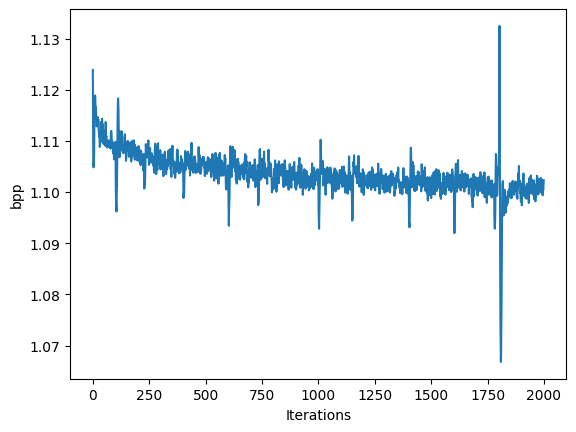

In [39]:
# ADMM
 
quality_loss_lambda = .5
num_iterations = 100
target_psnr = 35

model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(input_tensor,sr_image_tensor_orig, target_psnr,
                           quality_loss_lambda, num_iterations, model, model_compression, device=device, learningrate = 1e-4, Z_tensor=Z_tensor, T_tensor=T_tensor,
                           checkpoint_dir=CKPT_DIR)
loss_values_, bpp_values_, psnr_values_ = loss_values, bpp_values, psnr_values
plt.plot(bpp_values_)
plt.xlabel("Iterations")
plt.ylabel("bpp")
plt.show()

Outer 0 | Iter 0 | PSNR cmp: 34.34 | BPP: 1.1017 | Loss: 0.4950
Outer 0 | Iter 30 | PSNR cmp: 32.91 | BPP: 0.9997 | Loss: 0.3162
Outer 0 | Iter 60 | PSNR cmp: 32.62 | BPP: 0.9781 | Loss: 0.2809
Outer 0 | Iter 90 | PSNR cmp: 32.45 | BPP: 0.9651 | Loss: 0.2554
Checkpoint saved: outer 1/20 -> /content/drive/MyDrive/Skoltech/Science_Phan/runs/0008_nina/outer_0000.pt
Outer 1 | Iter 0 | PSNR cmp: 32.33 | BPP: 0.9578 | Loss: 0.2473
Outer 1 | Iter 30 | PSNR cmp: 31.86 | BPP: 0.9313 | Loss: 0.2194
Outer 1 | Iter 60 | PSNR cmp: 31.70 | BPP: 0.9198 | Loss: 0.2061
Outer 1 | Iter 90 | PSNR cmp: 31.78 | BPP: 0.9224 | Loss: 0.1937
Checkpoint saved: outer 2/20 -> /content/drive/MyDrive/Skoltech/Science_Phan/runs/0008_nina/outer_0001.pt
Outer 2 | Iter 0 | PSNR cmp: 31.73 | BPP: 0.9188 | Loss: 0.2139
Outer 2 | Iter 30 | PSNR cmp: 31.72 | BPP: 0.9179 | Loss: 0.1846
Outer 2 | Iter 60 | PSNR cmp: 31.73 | BPP: 0.9153 | Loss: 0.1704
Outer 2 | Iter 90 | PSNR cmp: 31.70 | BPP: 0.9139 | Loss: 0.1698
Checkpoint 

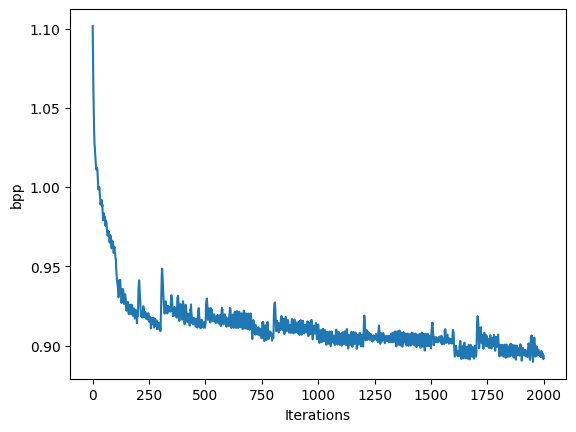

In [40]:
# ADMM
 
quality_loss_lambda = .2
num_iterations = 100
target_psnr = 35

model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(input_tensor,sr_image_tensor_orig, target_psnr,
                           quality_loss_lambda, num_iterations, model, model_compression, device=device, learningrate = 1e-4, Z_tensor=Z_tensor, T_tensor=T_tensor,
                           checkpoint_dir=CKPT_DIR)
loss_values_, bpp_values_, psnr_values_ = loss_values, bpp_values, psnr_values
plt.plot(bpp_values_)
plt.xlabel("Iterations")
plt.ylabel("bpp")
plt.show()

In [41]:
sr_compression_result_spnet_bitmin = eval_perf_compression(model_compression, Z_tensor, ground_truth_tensor)
sr_compression_result_spnet_bitmin

/tmp/ipykernel_9390/1750059163.py:33: UserWarning: Inference on GPU is not recommended for the autoregressive models (the entropy coder is run sequentially on CPU).
  sr_output = model_compression.compress(sr_image_tensor)


{'PSNR': array(35.352627, dtype=float32),
 'Bpp': array(0.8974031, dtype=float32),
 'Bpp(fsize)': 0.792755126953125,
 'SSIM': array(0.01930701, dtype=float32),
 'PSNR_cmpref': array(27.731018, dtype=float32),
 'SSI_cmpref': array(0.07327289, dtype=float32)}

Outer 0 | Iter 0 | PSNR cmp: 31.59 | BPP: 0.8963 | Loss: 1.4735
Outer 0 | Iter 30 | PSNR cmp: 31.46 | BPP: 0.9100 | Loss: -0.3734
Outer 0 | Iter 60 | PSNR cmp: 31.51 | BPP: 0.8913 | Loss: -0.4996
Outer 0 | Iter 90 | PSNR cmp: 31.51 | BPP: 0.8904 | Loss: -0.5042
Checkpoint saved: outer 1/20 -> /content/drive/MyDrive/Skoltech/Science_Phan/runs/0008_nina/outer_0000.pt
Outer 1 | Iter 0 | PSNR cmp: 31.50 | BPP: 0.8912 | Loss: 2.4721
Outer 1 | Iter 30 | PSNR cmp: 31.51 | BPP: 0.9073 | Loss: -0.4225
Outer 1 | Iter 60 | PSNR cmp: 31.53 | BPP: 0.8977 | Loss: -0.4688
Outer 1 | Iter 90 | PSNR cmp: 31.47 | BPP: 0.8924 | Loss: -0.4657
Checkpoint saved: outer 2/20 -> /content/drive/MyDrive/Skoltech/Science_Phan/runs/0008_nina/outer_0001.pt
Outer 2 | Iter 0 | PSNR cmp: 31.56 | BPP: 0.8966 | Loss: 0.0738
Outer 2 | Iter 30 | PSNR cmp: 31.48 | BPP: 0.8904 | Loss: -0.4734
Outer 2 | Iter 60 | PSNR cmp: 31.57 | BPP: 0.8930 | Loss: -0.4913
Outer 2 | Iter 90 | PSNR cmp: 31.47 | BPP: 0.8883 | Loss: -0.4842
Ch

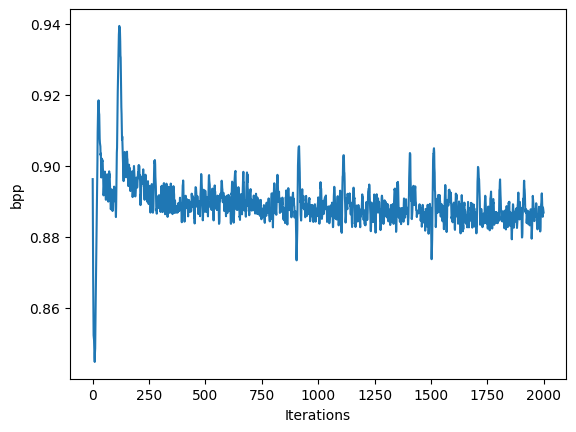

In [42]:
# ADMM
 
quality_loss_lambda = 1
num_iterations = 100
target_psnr = 32

model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(input_tensor,sr_image_tensor_orig, target_psnr,
                           quality_loss_lambda, num_iterations, model, model_compression, device=device, learningrate = 1e-4, Z_tensor=Z_tensor, T_tensor=T_tensor,
                           checkpoint_dir=CKPT_DIR)
loss_values_, bpp_values_, psnr_values_ = loss_values, bpp_values, psnr_values
plt.plot(bpp_values_)
plt.xlabel("Iterations")
plt.ylabel("bpp")
plt.show()

In [43]:
sr_compression_result_spnet_bitmin = eval_perf_compression(model_compression, Z_tensor, ground_truth_tensor)
sr_compression_result_spnet_bitmin

/tmp/ipykernel_9390/1750059163.py:33: UserWarning: Inference on GPU is not recommended for the autoregressive models (the entropy coder is run sequentially on CPU).
  sr_output = model_compression.compress(sr_image_tensor)


{'PSNR': array(32.97988, dtype=float32),
 'Bpp': array(0.8879566, dtype=float32),
 'Bpp(fsize)': 0.781158447265625,
 'SSIM': array(0.0481213, dtype=float32),
 'PSNR_cmpref': array(27.719147, dtype=float32),
 'SSI_cmpref': array(0.07420778, dtype=float32)}

[{'PSNR': array(33.162262, dtype=float32),
  'Bpp': array(1.2745446, dtype=float32),
  'Bpp(fsize)': 1.206451416015625,
  'SSIM': array(0.02922462, dtype=float32),
  'PSNR_cmpref': array(25.464651, dtype=float32),
  'SSI_cmpref': array(0.08608275, dtype=float32)},
 {'PSNR': array(36.905064, dtype=float32),
  'Bpp': array(0.77758557, dtype=float32),
  'Bpp(fsize)': 0.666900634765625,
  'SSIM': array(0.01620233, dtype=float32),
  'PSNR_cmpref': array(25.581451, dtype=float32),
  'SSI_cmpref': array(0.09474851, dtype=float32)},
 {'PSNR': array(35.746845, dtype=float32),
  'Bpp': array(0.89696914, dtype=float32),
  'Bpp(fsize)': 0.790802001953125,
  'SSIM': array(0.01841858, dtype=float32),
  'PSNR_cmpref': array(26.59946, dtype=float32),
  'SSI_cmpref': array(0.07771316, dtype=float32)}]

more lambdas with 32 difference pnsr